In [18]:
import pandas as pd
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import numpy as np
import os
winconsin = pd.read_csv("D:/Machine Learning/Cases/Wisconsin/BreastCancer.csv", index_col=0)
winconsin

,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
Code,,,,,,,,,,
61634,5,4,3,1,2,2,2,3,1,Benign
63375,9,1,2,6,4,10,7,7,2,Malignant
76389,10,4,7,2,2,8,6,1,1,Malignant
95719,6,10,10,10,8,10,7,10,7,Malignant
128059,1,1,1,1,2,5,5,1,1,Benign
...,...,...,...,...,...,...,...,...,...,...
1369821,10,10,10,10,5,10,10,10,7,Malignant
1371026,5,10,10,10,4,10,5,6,3,Malignant
1371920,5,1,1,1,2,1,3,2,1,Benign


In [19]:
le = LabelEncoder()
winconsin['Class'] = le.fit_transform(winconsin['Class'])
winconsin

,Clump,UniCell_Size,Uni_CellShape,MargAdh,SEpith,BareN,BChromatin,NoemN,Mitoses,Class
Code,,,,,,,,,,
61634,5,4,3,1,2,2,2,3,1,0
63375,9,1,2,6,4,10,7,7,2,1
76389,10,4,7,2,2,8,6,1,1,1
95719,6,10,10,10,8,10,7,10,7,1
128059,1,1,1,1,2,5,5,1,1,0
...,...,...,...,...,...,...,...,...,...,...
1369821,10,10,10,10,5,10,10,10,7,1
1371026,5,10,10,10,4,10,5,6,3,1
1371920,5,1,1,1,2,1,3,2,1,0


In [20]:
le.classes_

array(['Benign', 'Malignant'], dtype=object)

In [21]:
x,y = winconsin.drop('Class', axis=1), winconsin['Class']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 25, stratify=y)

In [22]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr.predict_proba(x_test)
lr.intercept_, lr.coef_

(array([-10.13685623]),
 array([[ 0.54707603,  0.04474491,  0.20952885,  0.19219542, -0.00722953,
          0.39656381,  0.60692755,  0.19441253,  0.53085196]]))

In [23]:
lr.predict_proba(x_test)

array([[9.98120767e-01, 1.87923285e-03],
       [9.98229749e-01, 1.77025092e-03],
       [1.96481629e-04, 9.99803518e-01],
       [9.82482033e-01, 1.75179672e-02],
       [9.94408267e-01, 5.59173308e-03],
       [5.51665724e-01, 4.48334276e-01],
       [2.05397996e-03, 9.97946020e-01],
       [9.76178351e-01, 2.38216491e-02],
       [9.98597104e-01, 1.40289575e-03],
       [9.96557412e-01, 3.44258849e-03],
       [9.99275706e-01, 7.24293521e-04],
       [9.98134279e-01, 1.86572114e-03],
       [5.46197681e-04, 9.99453802e-01],
       [9.89788038e-01, 1.02119620e-02],
       [9.89788038e-01, 1.02119620e-02],
       [9.98903064e-01, 1.09693596e-03],
       [1.16178478e-01, 8.83821522e-01],
       [9.98911740e-01, 1.08825963e-03],
       [9.98911740e-01, 1.08825963e-03],
       [9.90375598e-01, 9.62440163e-03],
       [9.96542540e-01, 3.45746032e-03],
       [7.31077129e-01, 2.68922871e-01],
       [4.51767821e-04, 9.99548232e-01],
       [4.26536006e-02, 9.57346399e-01],
       [9.958841

In [24]:
y_pred = lr.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0])

In [25]:
conf = confusion_matrix(y_test,y_pred)
print(conf)

acc = accuracy_score(y_test, y_pred)
acc

[[137   1]
 [  6  66]]


0.9666666666666667

#### Classifier is a probablity function

In [26]:
penalties = ['l1', 'l2', None]

for p in penalties:
    lr = LogisticRegression(penalty=p, solver='saga')
    lr.fit(x_train, y_train)
    y_pred = lr.predict(x_test)

    print(f"\n Accuracy with penalty {p} is: {accuracy_score(y_test,y_pred)}\n")


 Accuracy with penalty l1 is: 0.9666666666666667


 Accuracy with penalty l2 is: 0.9666666666666667


 Accuracy with penalty None is: 0.9666666666666667



c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/sanjayssane/SessionsMaterial/refs/heads/main/HR_comma_sep.csv")
x,y = df.drop('salary', axis=1), df['salary']

In [28]:
ohe = OneHotEncoder(drop = 'first', sparse_output = False).set_output(transform = 'pandas')
col_trnf = ColumnTransformer([('OHE', ohe, make_column_selector(dtype_include = object))],
                             remainder = 'passthrough',
                             verbose_feature_names_out=False)
col_trnf = col_trnf.set_output(transform = 'pandas')
x = col_trnf.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 25, stratify=y)


In [29]:
lr = LogisticRegression(solver='liblinear', penalty='l1')
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


              precision    recall  f1-score   support

        high       0.41      0.13      0.20       371
         low       0.52      0.75      0.61      2194
      medium       0.46      0.29      0.35      1934

    accuracy                           0.50      4499
   macro avg       0.46      0.39      0.39      4499
weighted avg       0.48      0.50      0.47      4499

0.49877750611246946


In [30]:
lr = LogisticRegression(solver='lbfgs', penalty='l2')
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.75      0.01      0.02       371
         low       0.52      0.67      0.59      2194
      medium       0.45      0.38      0.42      1934

    accuracy                           0.49      4499
   macro avg       0.57      0.36      0.34      4499
weighted avg       0.51      0.49      0.47      4499

0.49455434541009113


c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
lr = LogisticRegression(solver='lbfgs', penalty=None)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.00      0.00      0.00       371
         low       0.52      0.67      0.58      2194
      medium       0.45      0.39      0.42      1934

    accuracy                           0.49      4499
   macro avg       0.32      0.35      0.33      4499
weighted avg       0.44      0.49      0.46      4499

0.49144254278728605


c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users

In [32]:
solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
penalties = ['l2', None]
scores = []
for s in solvers:
    for p in penalties:
        lr = LogisticRegression(solver=s, penalty=p, max_iter=500)
        lr.fit(x_train, y_train)
        y_pred = lr.predict(x_test)
        scores.append([s,p,accuracy_score(y_test, y_pred)])
df_score = pd.DataFrame(scores, columns=['Solver', 'Penalty', 'Accuracy score'])
df_score.sort_values('Accuracy score', ascending=False)

c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown i

,Solver,Penalty,Accuracy score
6,sag,l2,0.499889
1,lbfgs,None,0.499667
7,sag,None,0.499667
2,newton-cg,l2,0.499667
4,newton-cholesky,l2,0.499444
5,newton-cholesky,None,0.499222
3,newton-cg,None,0.499222
0,lbfgs,l2,0.497888
9,saga,None,0.497444
8,saga,l2,0.497222


In [33]:
# solvers = ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
# penalties = ['l2', None]
# _c = np.linspace(0.001, 15, 20)
# scores = []
# for s in solvers:
#     for p in penalties:
#         for _ in _c:
#             lr = LogisticRegression(solver=s, penalty=p, max_iter=500, C=_)
#             lr.fit(x_train, y_train)
#             y_pred = lr.predict(x_test)
#             scores.append([_,s,p,accuracy_score(y_test, y_pred)])
# df_score = pd.DataFrame(scores, columns=['c', 'Solver', 'Penalty', 'Accuracy score'])
# df_score.sort_values('Accuracy score', ascending=False)

## ROC-AUC Curve

c:\Users\dbda.STUDENTSDC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


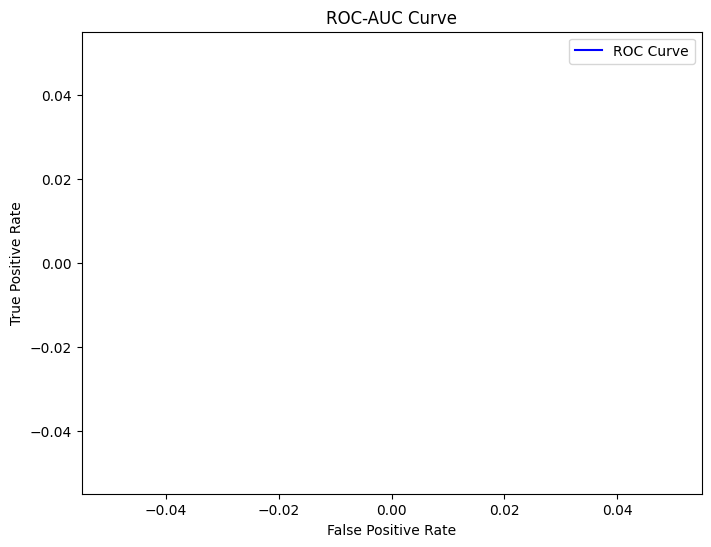

In [ ]:
# M-1

from sklearn.metrics import roc_curve, roc_auc_score,RocCurveDisplay
import matplotlib.pyplot as plt




y_pred_proba = lr.predict_proba(x_test)

# Create binary labels: class 1 vs rest
y_test_binary = (y_test == 1).astype(int)

auc_score = roc_auc_score(y_test_binary, y_pred_proba[:, 1])
print(f"AUC Score: {auc_score}")

fpr, tpr, thres = roc_curve(y_test_binary, y_pred_proba[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, c='blue', label='ROC Curve')
plt.scatter(fpr, tpr, c='red', s=20)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()


In [ ]:
# M-2 for ROC - AUC Curve